# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [1]:
from jedi.inference.gradual.typing import Callable
!pip install datasets


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /home/and/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/and/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [5]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f07ace40-0491-42bc-8ebb-4b4422fbeb54)')' thrown while requesting HEAD https://huggingface.co/datasets/ag_news/resolve/eb185aade064a813bc0b7f42de02595523103ca4/ag_news.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/and/.cache/huggingface/datasets/ag_news/default/0.0.0/eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Sun Oct 19 21:17:10 2025).


Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [6]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [7]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [8]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [9]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

In [10]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 2000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 128
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [11]:
def print_losses(losses):
    for (name, values), color in zip(losses.items(), ['red', 'blue']):
        plt.plot(np.arange(len(losses[name])), losses[name], color=color, label=name)

    plt.title('Losses')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

In [12]:
def print_acc(acc):
    for (name, values), color in zip(acc.items(), ['red', 'blue']):
        plt.plot(np.arange(len(acc[name][1:])), acc[name][1:], color=color, label=name)
        print(f"Лучшая accuracy для подхода {name}: {(max(acc[name]) * 100):.2f}")

    plt.title('Accuracy')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

### Запуск базовой модели с семинара на новом датасете

In [13]:
from typing import Literal

class ModelRRN(nn.Module):
    def __init__(
        self,
            vocab_size: int,
            padding_idx: int,
            embed_dim: int = 256,
            hidden_dim: int = 256,
            num_classes: int = 4,
            num_layers: int = 1,
            aggregation_type: Literal['max', 'mean'] = 'max',
            aggregation_with_last: bool = False,
            rnn_type: Literal['RNN', 'GRU', 'LSTM'] = 'RNN',
            dropout:float =  0.1,
        ):
        super().__init__()
        self.padding_idx = padding_idx
        # Слой эмбеддингов: сопоставляет каждому слову (индекс из словаря) вектор признаков
        # размерности hidden_dim.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=self.padding_idx)

        rnn_cls = {
            'RNN': nn.RNN,
            'GRU': nn.GRU,
            'LSTM': nn.LSTM,
        }[rnn_type]


        # batch_first=True -> вход имеет форму [batch_size, seq_len, hidden_dim].
        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )


        self.linear = nn.Linear(hidden_dim +  embed_dim if aggregation_with_last else hidden_dim, hidden_dim)

        # Проекционный слой в пространство классов. Размер выхода = num_classes (для AG News — 4).
        self.projection = nn.Linear(hidden_dim, num_classes)

        # Нелинейность и регуляризация.
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=dropout)

        # Тип агрегации признаков по времени: 'max' или 'mean'.
        self.aggregation_type = aggregation_type

        self.aggregation_with_last = aggregation_with_last

    def forward(self, input_batch:torch.Tensor) -> torch.Tensor:
        """
        Параметры:
            input_batch: LongTensor формы [batch_size, seq_len] — индексы слов.
        Возвращает:
            Логиты формы [batch_size, num_classes]. Для вероятностей применяйте softmax снаружи.
        """
        # Преобразуем индексы слов в эмбеддинги: [batch_size, seq_len, embed_dim]
        embeddings = self.embedding(input_batch)
        
        # Прогоняем через RNN. Выход: [batch_size, seq_len, hidden_dim]
        recurrent_output, _ = self.rnn(embeddings)

        # Агрегация по временной оси, получаем один вектор на объект.
        if self.aggregation_type == 'max':
            # Маска реальных токенов (True там, где не паддинг)
            mask = (input_batch != self.padding_idx)  # [B, T], bool

            # Заполняем паддинги −inf, чтобы они не могли стать максимумом
            neg_inf = torch.tensor(float('-inf'), device=recurrent_output.device, dtype=recurrent_output.dtype)
            masked_out = recurrent_output.masked_fill(~mask.unsqueeze(-1), neg_inf)  # [B, T, H]

            # Максимум  игнорируя паддинги
            agg_vec = masked_out.amax(dim=1)  # [B, H]

            # Фолбек на случай полностью «пустых» последовательностей (вся строка — паддинги)
            all_pad = (mask.sum(dim=1) == 0)
            if all_pad.any():
                agg_vec[all_pad] = 0.0
        elif self.aggregation_type == 'mean':

            mask = (input_batch != self.padding_idx).long()              # [B, T]
            lengths = mask.sum(dim=1).clamp(min=1)              # [B]

            # Маскируем выходы RNN и усредняем только по реальным токенам
            masked_out = recurrent_output * mask.unsqueeze(-1)  # [B, T, H]
            sum_out = masked_out.sum(dim=1)                     # [B, H]
            agg_vec = sum_out / lengths.unsqueeze(-1)    # [batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type. Используйте 'max' или 'mean'.")

        if self.aggregation_with_last:
            # Находим последний непаддинговый токен и берем его ЭМБЕДДИНГ (до RNN).

            mask = (input_batch != self.padding_idx).long()       # [batch_size, seq_len]
            lengths = mask.sum(dim=1)                             # [batch_size]
            last_idx = (lengths - 1).clamp(min=0)                 # [batch_size]
            bs = input_batch.size(0)
            last_idx_exp = last_idx.view(bs, 1, 1).expand(-1, 1, embeddings.size(-1))
            last_token_emb = embeddings.gather(dim=1, index=last_idx_exp).squeeze(1)  # [batch_size, hidden_dim]
            pooled_vec = torch.cat([agg_vec, last_token_emb], dim=-1)
        else:
            pooled_vec = agg_vec

        # Нелинейное преобразование + регуляризация.
        hidden = self.dropout(self.linear(self.non_lin(pooled_vec)))  # [batch_size, hidden_dim]
        
        # Проекция в логиты классов: [batch_size, num_classes]
        prediction = self.projection(self.non_lin(hidden))

        return prediction

In [14]:
def engine(num_epoch:int, train_dl:DataLoader, eval_dl:DataLoader):
    eval_steps = len(train_dl) // 2

    losses_type = {}
    acc_type = {}

    for rnn_type in ['RNN', 'GRU', 'LSTM']:
        for aggregation_type in ['max', 'mean']:
            for aggregation_with_last in [True, False]:
                for num_layers in [1,2,3]:


                    print(f"Starting training for rnn_type={rnn_type}, aggregation_type={aggregation_type}, aggregation_with_last={aggregation_with_last}, num_layers={num_layers}")
                    losses = []
                    acc = []

                    model = ModelRRN(
                        vocab_size=len(word2ind),
                        padding_idx=word2ind['<pad>'],
                        aggregation_type=aggregation_type,
                        aggregation_with_last=aggregation_with_last,
                        rnn_type=rnn_type,
                        num_layers=num_layers
                    )

                    model.to(device)
                    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
                    optimizer = torch.optim.Adam(model.parameters())

                    for epoch in range(num_epoch):
                        epoch_losses = []
                        model.train()
                        for i, batch in enumerate(tqdm(train_dl, desc=f'Training epoch {epoch}:')):
                            optimizer.zero_grad()
                            logits = model(batch['input_ids'])
                            loss = criterion(logits, batch['label'])
                            loss.backward()
                            optimizer.step()

                            epoch_losses.append(loss.item())
                            if i % eval_steps == 0:
                                model.eval()
                                acc.append(evaluate(model, eval_dl))
                                model.train()

                        losses.append(sum(epoch_losses) / len(epoch_losses))

                    losses_type[(rnn_type, aggregation_type,aggregation_with_last,  num_layers)] = losses
                    acc_type[(rnn_type, aggregation_type,aggregation_with_last,  num_layers)] = acc

    return losses_type, acc_type

In [15]:

losses_type, acc_type =  engine(
    5,
    train_dataloader,
    eval_dataloader
)

Starting training for rnn_type=RNN, aggregation_type=max, aggregation_with_last=True, num_layers=1


Training epoch 0::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/938 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/938 [00:00<?, ?it/s]

In [16]:
experiment_key = max(acc_type, key=lambda k: max(acc_type[k]))
values = max(acc_type[experiment_key])
print(f"Experiment {experiment_key} has maximum accuracy {values:.4f}")

Experiment ('LSTM', 'mean', False, 2) has maximum accuracy 0.9220


In [17]:
import json
with open("acc_type.json", "w", encoding="utf-8") as f:
    json.dump([ [list(k), v] for k, v in acc_type.items() ], f, indent=2, ensure_ascii=False)




### Подбор гиперпараметров и обучение до сходимости

In [18]:
from typing import Tuple
def search_best_params(num_epoch:int, train_dl:DataLoader, eval_dl:DataLoader, config:Tuple):
    eval_steps = len(train_dl) // 2

    losses_type = {}
    acc_type = {}

    for embed_dim in [128, 256, 512]:
        for hidden_dim in [128,256,512]:
            for dropout in [0.0, 0.1, 0.2]:



                    print(f"Starting training for embed_dim={embed_dim}, hidden_dim={hidden_dim}, dropout={dropout}")
                    losses = []
                    acc = []

                    model = ModelRRN(
                        embed_dim = embed_dim,
                        hidden_dim = hidden_dim,
                        vocab_size=len(word2ind),
                        padding_idx=word2ind['<pad>'],
                        aggregation_type=config[1],
                        aggregation_with_last=config[2],
                        rnn_type=config[0],
                        num_layers=config[3],
                        dropout=dropout,
                    )

                    model.to(device)
                    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
                    optimizer = torch.optim.Adam(model.parameters())

                    for epoch in range(num_epoch):
                        epoch_losses = []
                        model.train()
                        for i, batch in enumerate(tqdm(train_dl, desc=f'Training epoch {epoch}:')):
                            optimizer.zero_grad()
                            logits = model(batch['input_ids'])
                            loss = criterion(logits, batch['label'])
                            loss.backward()
                            optimizer.step()

                            epoch_losses.append(loss.item())
                            if i % eval_steps == 0:
                                model.eval()
                                acc.append(evaluate(model, eval_dl))
                                model.train()

                        losses.append(sum(epoch_losses) / len(epoch_losses))

                    losses_type[(embed_dim, hidden_dim,dropout)] = losses
                    acc_type[(embed_dim, hidden_dim,dropout)] = acc

    return losses_type, acc_type

In [19]:
losses_type, acc_type = search_best_params(
    10,
    train_dataloader,
    eval_dataloader,
    experiment_key
)

Starting training for embed_dim=128, hidden_dim=128, dropout=0.0


Training epoch 0::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/938 [00:00<?, ?it/s]

...

Training epoch 5::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/938 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/938 [00:00<?, ?it/s]

In [22]:
experiment_key = max(acc_type, key=lambda k: max(acc_type[k]))
values = max(acc_type[experiment_key])
print(f"Experiment {experiment_key} has maximum accuracy {values:.8f}")

Experiment (512, 512, 0.1) has maximum accuracy 0.92200005


### Анализ графиков

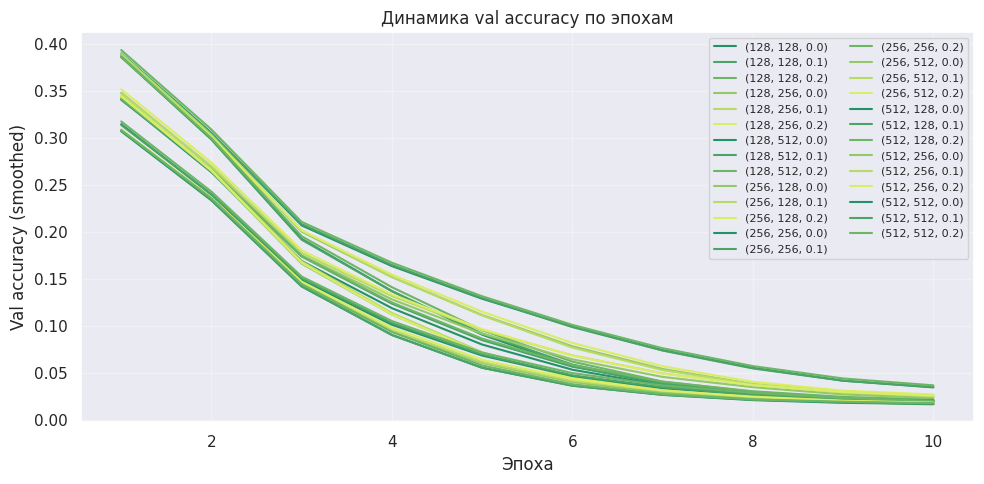

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# функция сглаживания (если её ещё нет)
def smooth(x, k=3):
    if k <= 1:
        return np.asarray(x)
    x = np.asarray(x)
    pad = k // 2
    xpad = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(k) / k
    return np.convolve(xpad, kernel, mode='valid')

plt.figure(figsize=(10, 5))
for key, d in losses_type.items():
    series = d  # d — это список accuracy
    y = smooth(series, k=3)
    epochs = range(1, len(y) + 1)
    plt.plot(epochs, y, label=str(key))

plt.xlabel('Эпоха')
plt.ylabel('loss (smoothed)')
plt.title('Динамика loss по эпохам')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

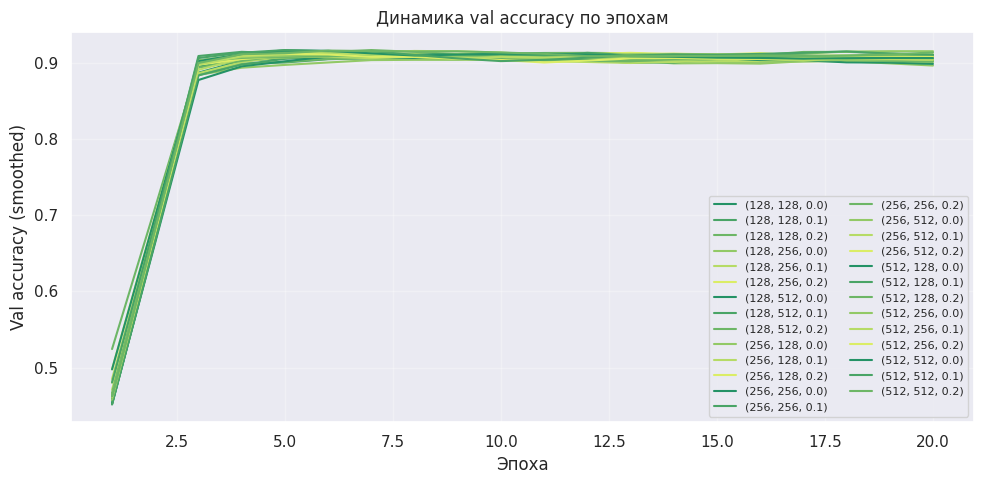

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# функция сглаживания (если её ещё нет)
def smooth(x, k=3):
    if k <= 1:
        return np.asarray(x)
    x = np.asarray(x)
    pad = k // 2
    xpad = np.pad(x, (pad, pad), mode='edge')
    kernel = np.ones(k) / k
    return np.convolve(xpad, kernel, mode='valid')

plt.figure(figsize=(10, 5))
for key, d in acc_type.items():
    series = d  # d — это список accuracy
    y = smooth(series, k=3)
    epochs = range(1, len(y) + 1)
    plt.plot(epochs, y, label=str(key))

plt.xlabel('Эпоха')
plt.ylabel('Val accuracy (smoothed)')
plt.title('Динамика val accuracy по эпохам')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

### Выводы

Что приносит улучшение(эксперименты на 5 эпохах):
- Изменения lstm/gru/rnn.
    - lstm(acc=0.9220 mean, aggregation_with_last=False, num_layers=2) - лучший результат
    - gru(acc=0.9215  mean, True, 2)
    - rnn(acc=0.9135  mean, True, 1)
- Тип агрегации: mean‑агрегация даёт небольшой, но стабильный прирост относительно max.
- Архитектура после применения RNN - слабо влияет
- Количество рекурентных слоев - дает небольшой эффект. Лучше всего результаты при 2 слоях. При 3 результаты могут ухудшиться.

По результатам лучшая конфигурация 'LSTM', тип агрегации = mean, без конкатинации с эмбедингом с последнего токена, 2 рекурентных слоя. Для нее проведем поиски лучших значений дропаута, размеров ембединга, и размеров скрытого слоя.

Изменение размеров эмбедингов и размеров скрытого слоя, а также изменение значений дропаута не дает особого эффекта.
Наблюдается стабильная сходимость.






